<a href="https://colab.research.google.com/github/teju917/Machine_learning_lab2/blob/main/baggingandboosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ORIGINAL DATASET
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2  

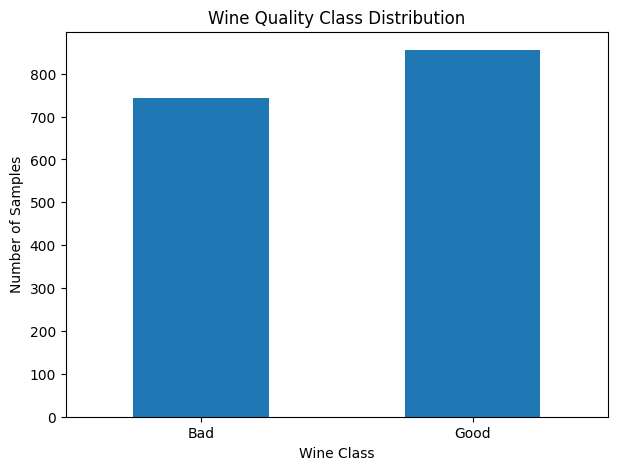

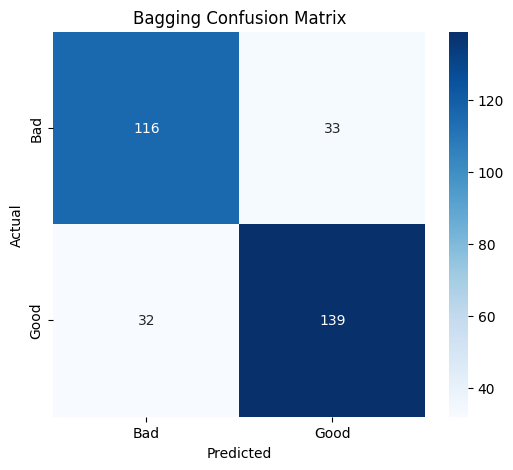

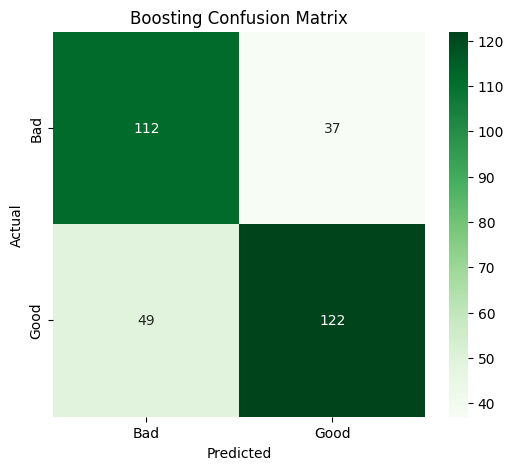


PERFORMANCE METRICS
      Metric   Bagging  Boosting
0  Precision  0.808140  0.767296
1     Recall  0.812865  0.713450
2   F1-Score  0.810496  0.739394


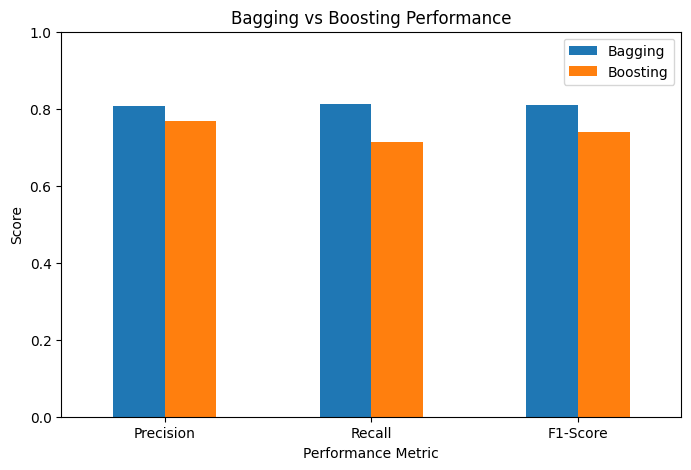

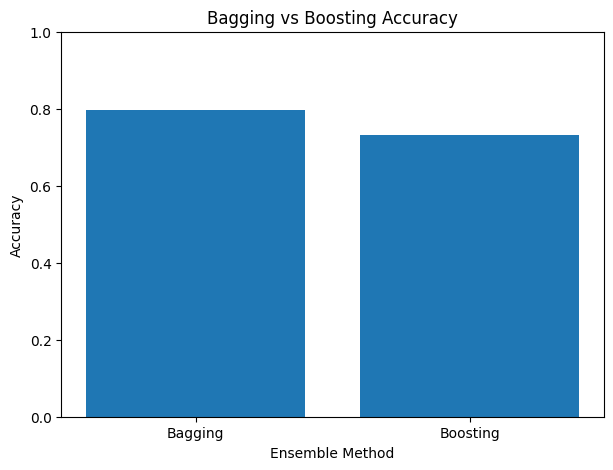

In [2]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("ORIGINAL DATASET")
print(df.head())

print("\nDATASET INFORMATION")
print("Total examples:", len(df))
print("Number of columns:", len(df.columns))

print("\nQUALITY DISTRIBUTION")
print(df["quality"].value_counts().sort_index())

df["quality"] = df["quality"].apply(
    lambda x: 1 if x >= 6 else 0
)

print("\nPREPROCESSED DATASET")
print(df.head())

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTRAINING EXAMPLES:", len(X_train))
print("TESTING EXAMPLES:", len(X_test))

base_model = DecisionTreeClassifier(
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)
boosting_model.fit(X_train, y_train)

bagging_prediction = bagging_model.predict(X_test)
boosting_prediction = boosting_model.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_prediction
)

boosting_accuracy = accuracy_score(
    y_test,
    boosting_prediction
)

print("\n" + "=" * 60)
print("BAGGING RESULTS")
print("=" * 60)

print("Accuracy:", round(bagging_accuracy, 4))

print(
    classification_report(
        y_test,
        bagging_prediction
    )
)

print("\n" + "=" * 60)
print("BOOSTING RESULTS")
print("=" * 60)

print("Accuracy:", round(boosting_accuracy, 4))

print(
    classification_report(
        y_test,
        boosting_prediction
    )
)

comparison = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [
        bagging_accuracy,
        boosting_accuracy
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison)

plt.figure(figsize=(7, 5))

df["quality"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.title("Wine Quality Class Distribution")
plt.xticks(
    [0, 1],
    ["Bad", "Good"],
    rotation=0
)

plt.show()

bagging_cm = confusion_matrix(
    y_test,
    bagging_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    bagging_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad", "Good"],
    yticklabels=["Bad", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion Matrix")

plt.show()

boosting_cm = confusion_matrix(
    y_test,
    boosting_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    boosting_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Bad", "Good"],
    yticklabels=["Bad", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Boosting Confusion Matrix")

plt.show()

report_bagging = classification_report(
    y_test,
    bagging_prediction,
    output_dict=True
)

report_boosting = classification_report(
    y_test,
    boosting_prediction,
    output_dict=True
)

metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Bagging": [
        report_bagging["1"]["precision"],
        report_bagging["1"]["recall"],
        report_bagging["1"]["f1-score"]
    ],
    "Boosting": [
        report_boosting["1"]["precision"],
        report_boosting["1"]["recall"],
        report_boosting["1"]["f1-score"]
    ]
})

print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

print(metrics)

metrics_plot = metrics.set_index("Metric")

metrics_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Performance Metric")
plt.ylabel("Score")
plt.title("Bagging vs Boosting Performance")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Ensemble Method")
plt.ylabel("Accuracy")
plt.title("Bagging vs Boosting Accuracy")
plt.ylim(0, 1)

plt.show()